In [2]:
import torch
from torch import nn
from torch.nn import init
import numpy as np
import sys
sys.path.append('..')
from d2l import torch as d2l_torch

In [3]:
class FlattenLayer(nn.Module):
    def __init__(self):
        super(FlattenLayer, self).__init__()
    def forward(self, x):
        return x.view(x.shape[0], -1)

In [4]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

net = nn.Sequential(
    FlattenLayer(),
    nn.Linear(num_inputs, num_hiddens),
    nn.ReLU(),
    nn.Linear(num_hiddens, num_outputs)
)

for params in net.parameters():
    init.normal_(params, mean=0, std=0.01)

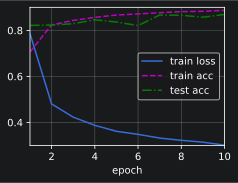

In [5]:
train_iter, test_iter = d2l_torch.load_data_fashion_mnist(batch_size=256)
loss = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(net.parameters(), lr=0.5)

num_epochs = 5
d2l_torch.train_ch3(net, train_iter, test_iter, loss, num_outputs, optimizer)

In [8]:
class Module_ModuleList(nn.Module):
    def __init__(self):
        super(Module_ModuleList, self).__init__()
        self.linears = nn.ModuleList([nn.Linear(10, 10)])

class Module_List(nn.Module):
    def __init__(self):
        super(Module_List, self).__init__()
        self.linears = [nn.Linear(10, 10)]

net1 = Module_ModuleList()
net2 = Module_List()

print("net1:")
for p in net1.parameters():
    print(p.size())

print("net2:")
for p in net2.parameters():
    print(p)


net1:
<generator object Module.parameters at 0x0000029B74EC3DF0>
torch.Size([10, 10])
torch.Size([10])
net2:
